Project2 - Salary Predict(Regression)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [2]:
data_dir = "/content/drive/MyDrive/InternProject2_Salary_Predict/Salary Data.csv"

In [3]:
data = pd.read_csv(data_dir)
data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [5]:
print("\nMissing values:\n", data.isnull().sum())
print("\nBasic stats:\n", data.describe())


Missing values:
 Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

Basic stats:
               Age  Years of Experience         Salary
count  373.000000           373.000000     373.000000
mean    37.431635            10.030831  100577.345845
std      7.069073             6.557007   48240.013482
min     23.000000             0.000000     350.000000
25%     31.000000             4.000000   55000.000000
50%     36.000000             9.000000   95000.000000
75%     44.000000            15.000000  140000.000000
max     53.000000            25.000000  250000.000000


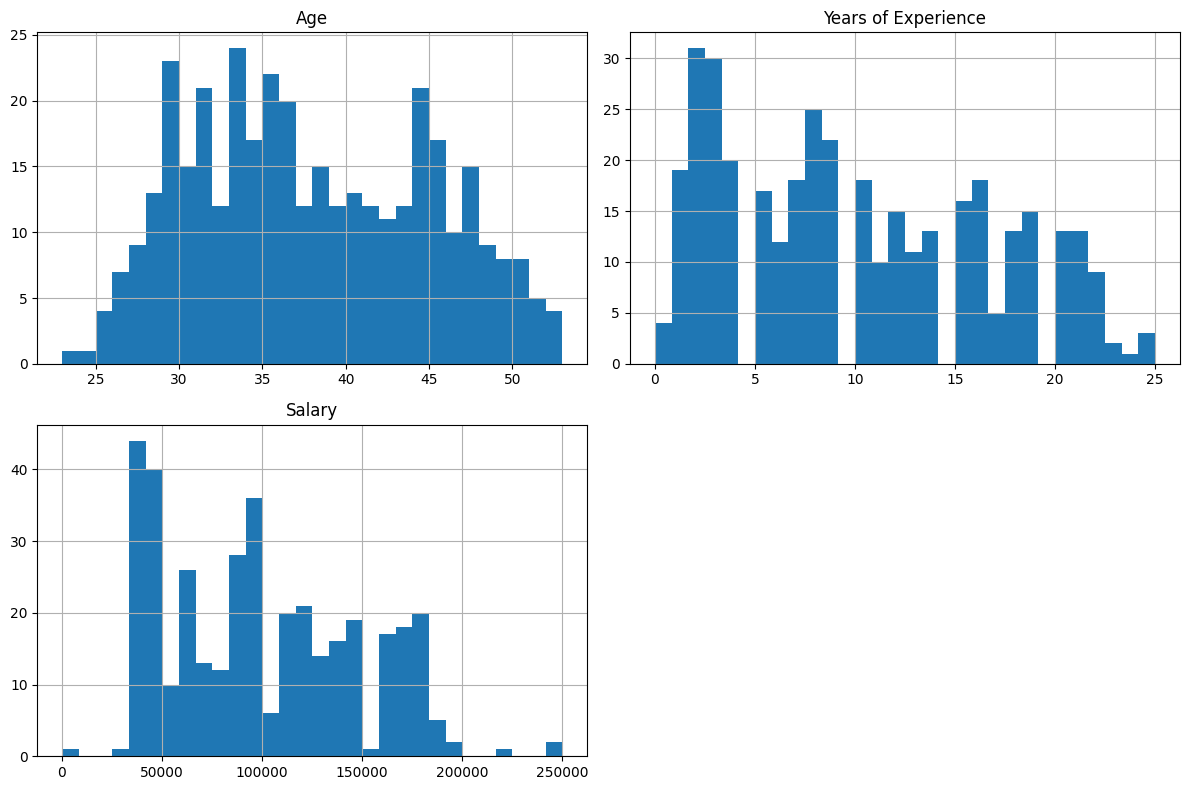

In [6]:
data.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [7]:
data = data.dropna()
print("Shape after dropping nulls:", data.shape)

Shape after dropping nulls: (373, 6)


Handle categorical features

In [8]:
print(data['Gender'].unique())
print(data['Education Level'].unique())
print(data['Job Title'].unique())

# Encode Gender (binary)
data['Gender'] = LabelEncoder().fit_transform(data['Gender'])  # Male=1, Female=0

# Encode Education Level (ordinal — order matters)
edu_order = {"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3}
data['Education Level'] = data['Education Level'].map(edu_order)

# Encode Job Title (too many unique values — use LabelEncoder)
data['Job Title'] = LabelEncoder().fit_transform(data['Job Title'])

print(data.head())

['Male' 'Female']
["Bachelor's" "Master's" 'PhD']
['Software Engineer' 'Data Analyst' 'Senior Manager' 'Sales Associate'
 'Director' 'Marketing Analyst' 'Product Manager' 'Sales Manager'
 'Marketing Coordinator' 'Senior Scientist' 'Software Developer'
 'HR Manager' 'Financial Analyst' 'Project Manager' 'Customer Service Rep'
 'Operations Manager' 'Marketing Manager' 'Senior Engineer'
 'Data Entry Clerk' 'Sales Director' 'Business Analyst' 'VP of Operations'
 'IT Support' 'Recruiter' 'Financial Manager' 'Social Media Specialist'
 'Software Manager' 'Junior Developer' 'Senior Consultant'
 'Product Designer' 'CEO' 'Accountant' 'Data Scientist'
 'Marketing Specialist' 'Technical Writer' 'HR Generalist'
 'Project Engineer' 'Customer Success Rep' 'Sales Executive' 'UX Designer'
 'Operations Director' 'Network Engineer' 'Administrative Assistant'
 'Strategy Consultant' 'Copywriter' 'Account Manager'
 'Director of Marketing' 'Help Desk Analyst' 'Customer Service Manager'
 'Business Intelligenc

Feature engineering

In [9]:
# Age relative to experience
data['Age_Experience_Ratio'] = data['Age'] / (data['Years of Experience'] + 1)

# Seniority — experience grouped into levels
data['Seniority'] = pd.cut(
    data['Years of Experience'],
    bins=[0, 2, 5, 10, 20, 100],
    labels=[0, 1, 2, 3, 4],
    include_lowest=True
).astype(int)

# Education + Experience combined signal
data['Edu_Exp_Score'] = data['Education Level'] * data['Years of Experience']

print(data.head())

    Age  Gender  Education Level  Job Title  Years of Experience    Salary  \
0  32.0       1                1        159                  5.0   90000.0   
1  28.0       0                2         17                  3.0   65000.0   
2  45.0       1                3        130                 15.0  150000.0   
3  36.0       0                1        101                  7.0   60000.0   
4  52.0       1                2         22                 20.0  200000.0   

   Age_Experience_Ratio  Seniority  Edu_Exp_Score  
0              5.333333          1            5.0  
1              7.000000          1            6.0  
2              2.812500          3           45.0  
3              4.500000          2            7.0  
4              2.476190          3           40.0  


In [10]:
target = 'Salary'

X = data.drop(target, axis=1)
y = data[target]

print("Features:", X.columns.tolist())



Features: ['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Age_Experience_Ratio', 'Seniority', 'Edu_Exp_Score']


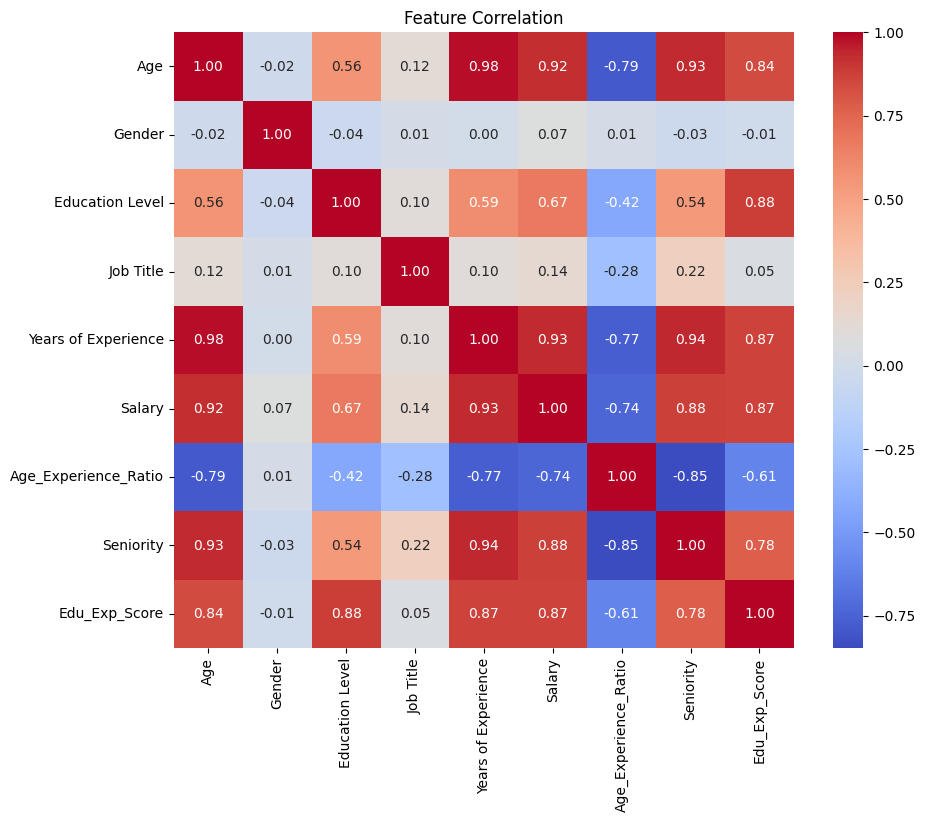

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

Years of Experince have the highest impact on salary

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (298, 8), Test: (75, 8)


 Model 1: Single feature (Experience)

In [13]:
exp_index      = X.columns.tolist().index('Years of Experience')
X_train_single = X_train_scaled[:, exp_index].reshape(-1, 1)
X_test_single  = X_test_scaled[:, exp_index].reshape(-1, 1)

model_single = LinearRegression()
model_single.fit(X_train_single, y_train)

y_pred_single = model_single.predict(X_test_single)

rmse_single = np.sqrt(mean_squared_error(y_test, y_pred_single))
r2_single   = r2_score(y_test, y_pred_single)

print("=== Single Feature Model (Experience) ===")
print(f"RMSE : {rmse_single:,.2f}")
print(f"R²   : {r2_single:.4f}")

=== Single Feature Model (Experience) ===
RMSE : 15,551.04
R²   : 0.8991


Model 2: Multiple features

In [14]:
model_multi = LinearRegression()
model_multi.fit(X_train_scaled, y_train)

y_pred_multi = model_multi.predict(X_test_scaled)

rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi   = r2_score(y_test, y_pred_multi)

print("=== Multiple Feature Model ===")
print(f"RMSE : {rmse_multi:,.2f}")
print(f"R²   : {r2_multi:.4f}")

=== Multiple Feature Model ===
RMSE : 15,744.23
R²   : 0.8966


Compare both models

                      Model         RMSE       R²
Single Feature (Experience) 15551.041248 0.899134
          Multiple Features 15744.230400 0.896612


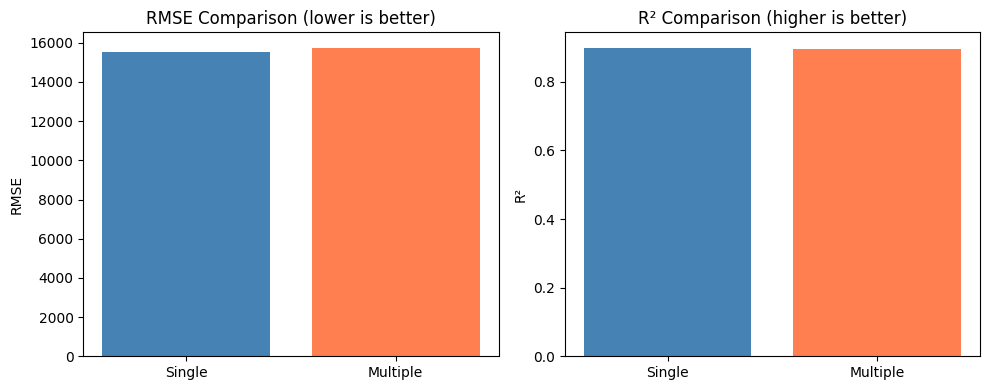

In [15]:
comparison = pd.DataFrame({
    'Model' : ['Single Feature (Experience)', 'Multiple Features'],
    'RMSE'  : [rmse_single, rmse_multi],
    'R²'    : [r2_single, r2_multi]
})
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Single', 'Multiple'], [rmse_single, rmse_multi], color=['steelblue', 'coral'])
axes[0].set_title('RMSE Comparison (lower is better)')
axes[0].set_ylabel('RMSE')

axes[1].bar(['Single', 'Multiple'], [r2_single, r2_multi], color=['steelblue', 'coral'])
axes[1].set_title('R² Comparison (higher is better)')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()

Actual vs Predicted + Residual plot

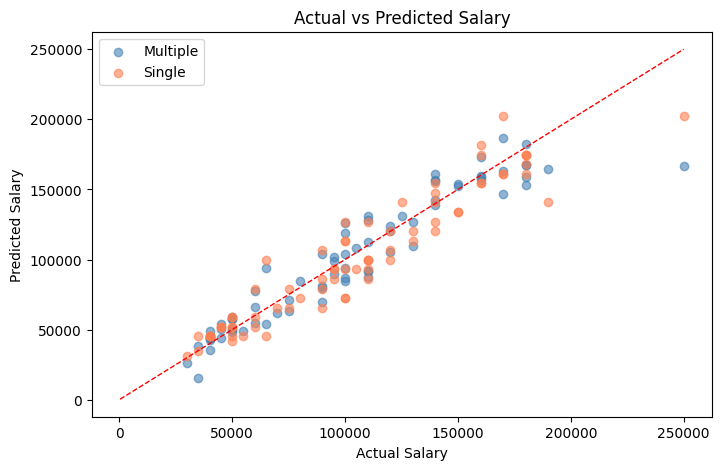

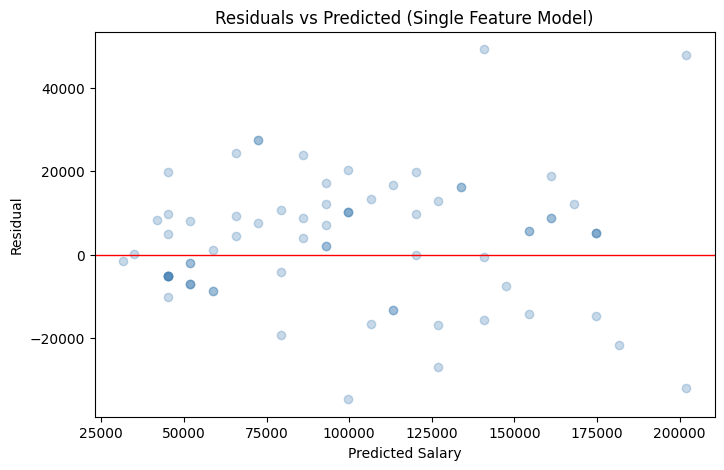

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_multi, alpha=0.6, color='steelblue', label='Multiple')
plt.scatter(y_test, y_pred_single, alpha=0.6, color='coral', label='Single')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=1)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.show()

residuals = y_test - y_pred_single

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_single, residuals, alpha=0.3, color='steelblue')
plt.axhline(0, color='red', linewidth=1)
plt.xlabel('Predicted Salary')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted (Single Feature Model)')
plt.show()

Save best model

In [17]:
joblib.dump(model_single, 'salary_model.pkl')
joblib.dump(scaler,       'salary_scaler.pkl')

print("Best Model : Single Feature Model (Years of Experience)")
print(f"RMSE       : {rmse_single:,.2f}")
print(f"R²         : {r2_single:.4f}")
print("Model and scaler saved.")

Best Model : Single Feature Model (Years of Experience)
RMSE       : 15,551.04
R²         : 0.8991
Model and scaler saved.


In [18]:
from google.colab import files

loaded_model  = joblib.load('salary_model.pkl')
loaded_scaler = joblib.load('salary_scaler.pkl')

sample        = X_test.sample(5, random_state=42)
sample_scaled = loaded_scaler.transform(sample)

exp_index = X.columns.tolist().index('Years of Experience')
preds     = loaded_model.predict(sample_scaled[:, exp_index].reshape(-1, 1))

results = pd.DataFrame({
    'Actual Salary'   : y_test.loc[sample.index].values,
    'Predicted Salary': preds.round(2),
    'Difference'      : (y_test.loc[sample.index].values - preds).round(2)
})
print(results.to_string(index=False))

files.download('salary_model.pkl')
files.download('salary_scaler.pkl')

 Actual Salary  Predicted Salary  Difference
      140000.0         147505.11    -7505.11
       75000.0          65634.03     9365.97
      140000.0         120214.75    19785.25
      180000.0         174795.47     5204.53
       35000.0          34932.37       67.63


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>